1.Read CSV: Write a Python script to open employee_data.csv and print the first 5 rows.

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/dipusardar/DIPU/Programming/Data-Analysis/Project 03/employee_data.csv")

print(df.head(5))

   EmployeeID            Name   Department  Age   Salary    JoinDate  \
0         101    Alex Johnson        Sales   28  55000.0  2022-03-15   
1         102      Biplob Roy  Engineering   32  85000.0  2021-06-01   
2         103  Chandra Sarker           HR   45  65000.0  2018-11-12   
3         104    David Miller  Engineering   24  70000.0  2023-01-10   
4         105     Emma Watson    Marketing   30      NaN  2020-09-05   

   PerformanceScore Remote  
0               8.5    Yes  
1               9.0     No  
2               7.2    Yes  
3               8.1    Yes  
4               6.8     No  


2.Convert to Array: Convert the Salary column into a NumPy array (skip or remove any empty values)

In [125]:
array_salary = np.array(df['Salary'].dropna())

print(array_salary)

[ 55000.  85000.  65000.  70000.  58000.  95000.  52000.  48000.  72000.
 105000.  56000.  67000.  61000.  88000.]


3. Salary Raise: Use the NumPy array to give everyone a 10% raise. Print the original and new salaries.

In [126]:
print("Original Salaries")
print(array_salary)

print("New salaries")
bonus = np.array(array_salary * 1.1)
print(bonus)


Original Salaries
[ 55000.  85000.  65000.  70000.  58000.  95000.  52000.  48000.  72000.
 105000.  56000.  67000.  61000.  88000.]
New salaries
[ 60500.  93500.  71500.  77000.  63800. 104500.  57200.  52800.  79200.
 115500.  61600.  73700.  67100.  96800.]


4. Basic Statistics: Find the Mean (average), Median, and Standard Deviation of the Age column using NumPy.

In [127]:
Array = np.array(df['Age'])
print(Array.mean())
print(Array.std())
print(np.median(Array))





33.93333333333333
7.628601153262344
32.0


5. Filter Scores: Use NumPy to find and print all performance scores that are greater than 8.0.

In [128]:
print(df.columns)
PerformanceScore_print = np.array(df['PerformanceScore'].dropna())

result = PerformanceScore_print[PerformanceScore_print > 8]
print(result)

Index(['EmployeeID', 'Name', 'Department', 'Age', 'Salary', 'JoinDate',
       'PerformanceScore', 'Remote'],
      dtype='str')
[8.5 9.  8.1 9.5 8.8 9.8 8.4]


Phase 2: Pandas Data Manipulation

6. Load & Summary: Load the CSV file into a Pandas DataFrame. Display .info() and .describe().

In [129]:
import pandas as pd
df = pd.read_csv('/Users/dipusardar/DIPU/Programming/Data-Analysis/Project 03/employee_data.csv')

print(df.head())
print(df.info())
print(df.describe())

   EmployeeID            Name   Department  Age   Salary    JoinDate  \
0         101    Alex Johnson        Sales   28  55000.0  2022-03-15   
1         102      Biplob Roy  Engineering   32  85000.0  2021-06-01   
2         103  Chandra Sarker           HR   45  65000.0  2018-11-12   
3         104    David Miller  Engineering   24  70000.0  2023-01-10   
4         105     Emma Watson    Marketing   30      NaN  2020-09-05   

   PerformanceScore Remote  
0               8.5    Yes  
1               9.0     No  
2               7.2    Yes  
3               8.1    Yes  
4               6.8     No  
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        15 non-null     int64  
 1   Name              15 non-null     str    
 2   Department        15 non-null     str    
 3   Age               15 non-null     int64  
 4   Salary         

7. Fix Missing Values: Fill the missing value in Salary with the median salary. Fill the missing PerformanceScore with the mean score.

In [130]:
print(df.columns)

salary_median = df['Salary'].median()

df['Salary'] = df['Salary'].fillna(salary_median)


score_mean = df['PerformanceScore'].mean()

df['PerformanceScore'] = df['PerformanceScore'].fillna(score_mean)

Index(['EmployeeID', 'Name', 'Department', 'Age', 'Salary', 'JoinDate',
       'PerformanceScore', 'Remote'],
      dtype='str')


8. Filter Rows: Show rows where the department is "Engineering" and Remote is "Yes".

In [131]:
result_df = df[(df['Department']=='Engineering') & (df['Remote'] == 'Yes')]

print(result_df)

    EmployeeID          Name   Department  Age   Salary    JoinDate  \
3          104  David Miller  Engineering   24  70000.0  2023-01-10   
14         115   Oscar Isaac  Engineering   36  88000.0  2019-12-01   

    PerformanceScore Remote  
3                8.1    Yes  
14               8.4    Yes  


9. Group By Department: Group by Department and calculate the average salary and average performance score for each.

In [132]:
groups = df.groupby('Department')[['Salary','PerformanceScore']].mean()

print(groups)

                   Salary  PerformanceScore
Department                                 
Engineering  88600.000000          8.960000
HR           61333.333333          7.233333
Marketing    66333.333333          7.666667
Sales        54250.000000          7.866071


10. Find Top Earners: Find the top 3 highest-paid employees. Sort them from highest to lowest salary.

In [133]:
higher_pay = df.sort_values(by='Salary', ascending=False).head(3).reset_index(drop=True)

print(higher_pay)

   EmployeeID           Name   Department  Age    Salary    JoinDate  \
0         111  Kevin Mitnick  Engineering   42  105000.0  2014-08-18   
1         107       Gita Das  Engineering   40   95000.0  2017-02-14   
2         115    Oscar Isaac  Engineering   36   88000.0  2019-12-01   

   PerformanceScore Remote  
0               9.8     No  
1               9.5     No  
2               8.4    Yes  


10. Date Column: Convert JoinDate to a datetime type. Create a new column named JoinYear with just the year.

In [134]:
print(df.columns)
df['JoinDate'] = pd.to_datetime(df['JoinDate'])
df['JoinYear'] = df['JoinDate'].dt.year

print(df['JoinYear'])

Index(['EmployeeID', 'Name', 'Department', 'Age', 'Salary', 'JoinDate',
       'PerformanceScore', 'Remote'],
      dtype='str')
0     2022
1     2021
2     2018
3     2023
4     2020
5     2019
6     2017
7     2022
8     2023
9     2015
10    2014
11    2021
12    2012
13    2022
14    2019
Name: JoinYear, dtype: int32



12. Count Values: Count how many employees work remote ("Yes") vs in-office ("No").

In [135]:
counts = df.value_counts("Remote")

print(counts)

Remote
Yes    8
No     7
Name: count, dtype: int64


Phase 3: Matplotlib Visualization

13. Age Histogram: Plot a simple histogram of the Age column. Add a title and axis labels

Index(['EmployeeID', 'Name', 'Department', 'Age', 'Salary', 'JoinDate',
       'PerformanceScore', 'Remote', 'JoinYear'],
      dtype='str')


Text(0, 0.5, 'Frequancy Count')

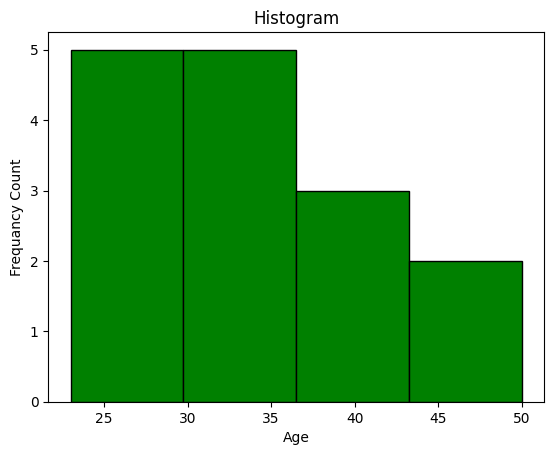

In [136]:
print(df.columns)
plt.hist(
    df['Age'],
    bins=4,
    color=['green'],
    edgecolor='black'
)

plt.title('Histogram')
plt.xlabel('Age')
plt.ylabel('Frequancy Count')


14. Department Bar Chart: Create a bar chart showing the number of employees in each department.

Index(['EmployeeID', 'Name', 'Department', 'Age', 'Salary', 'JoinDate',
       'PerformanceScore', 'Remote', 'JoinYear'],
      dtype='str')


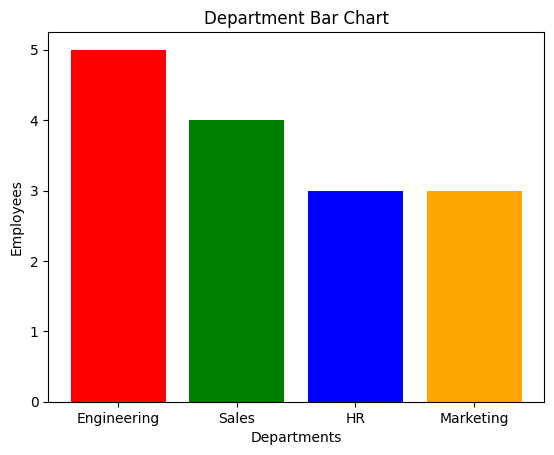

In [137]:
import pandas as pd
print(df.columns)
bar_chart = df['Department'].value_counts()

plt.bar(
    bar_chart.index,
    bar_chart.values,
    color=['red', 'green','blue','orange']
)
plt.title('Department Bar Chart')
plt.xlabel('Departments')
plt.ylabel('Employees')

plt.show()

15. Salary Scatter Plot: Make a scatter plot with Age on the X-axis and Salary on the Y-axis.

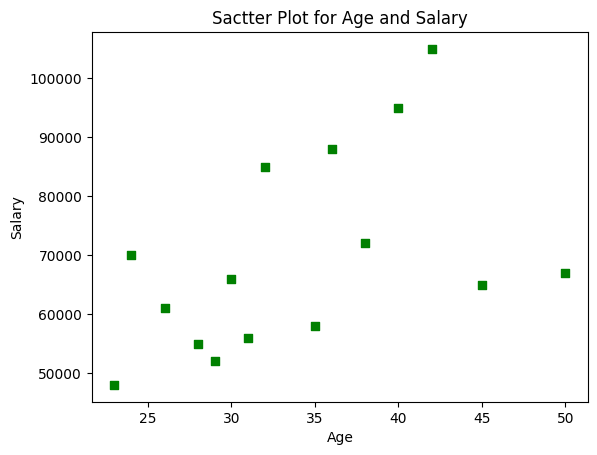

In [138]:
plt.scatter(
    df['Age'],
    df['Salary'],

    color='Green',
    marker='s'
)
plt.title("Sactter Plot for Age and Salary")
plt.xlabel('Age')
plt.ylabel('Salary')

plt.show()

16. Salary Pie Chart: Create a pie chart showing the percentage of total salary spent on each department.

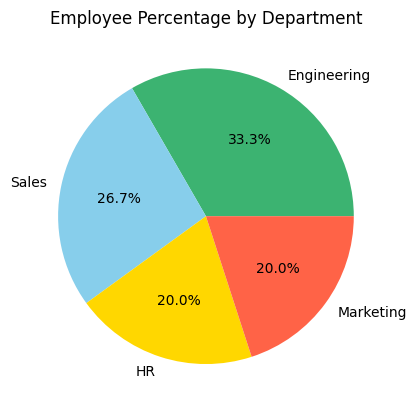

In [147]:
# শুধু কলামটি পরিবর্তন করে 'Department' করে দিন
pie_chart = df['Department'].value_counts()

plt.pie(
    pie_chart.values,          # প্রফেশনাল প্র্যাকটিস: .values স্পষ্ট করে দেওয়া
    labels=pie_chart.index,
    colors=['mediumseagreen', 'skyblue', 'gold', 'tomato'],
    autopct='%1.1f%%'
)
plt.title("Employee Percentage by Department")
plt.savefig('department_pie.png')